In [1]:
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, log_loss, classification_report
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
os.getcwd()

'C:\\Users\\bhoom\\ML-Based Demand Estimation and Pricing Agent\\Demand Estimation and Pricing Agent_Part 1\\agents\\models'

In [3]:
os.listdir("../")

['.DS_Store',
 '.ipynb_checkpoints',
 'dummy_fixed_prices.py',
 'dummy_fixed_prices_adaptive.py',
 'main.py',
 'models',
 'static_prices_submission.csv',
 '__init__.py',
 '__pycache__']

In [4]:
os.listdir("../../data")


['datafile1_2025.csv',
 'datafile2_2025.csv',
 'data_helpers_2025.ipynb',
 'test_user_info_2025.csv',
 'train_prices_decisions_2025.csv']

reads in training data and convert item bought column to numberic for logistic regression (currently set as True/False)

In [10]:
train_df = pd.read_csv("../../data/train_prices_decisions_2025.csv")
train_df

,user_index,Covariate1,Covariate2,Covariate3,price_item,item_bought
0,0,1.396069,0.228525,9.790878,0.010000,True
1,1,5.201819,2.212083,10.549586,50.563709,True
2,2,5.471765,0.568564,12.706814,82.305243,True
3,3,3.002355,1.185335,5.513210,38.611238,True
4,4,1.337119,1.374958,6.298567,86.705523,False
...,...,...,...,...,...,...
49995,49995,6.921727,1.362905,6.257731,375.348066,False
49996,49996,1.706747,1.921548,12.139479,118.039923,False
49997,49997,5.270051,1.584286,8.507552,0.010000,True
49998,49998,2.447797,2.340020,5.929868,53.780429,False


In [12]:
train_df['item_bought'] = train_df['item_bought'].astype(int)
train_df

,user_index,Covariate1,Covariate2,Covariate3,price_item,item_bought
0,0,1.396069,0.228525,9.790878,0.010000,1
1,1,5.201819,2.212083,10.549586,50.563709,1
2,2,5.471765,0.568564,12.706814,82.305243,1
3,3,3.002355,1.185335,5.513210,38.611238,1
4,4,1.337119,1.374958,6.298567,86.705523,0
...,...,...,...,...,...,...
49995,49995,6.921727,1.362905,6.257731,375.348066,0
49996,49996,1.706747,1.921548,12.139479,118.039923,0
49997,49997,5.270051,1.584286,8.507552,0.010000,1
49998,49998,2.447797,2.340020,5.929868,53.780429,0


seperates features x and y, fits the scaler so that all are compared at the same level/scale, and fits the logistic regression model

In [15]:
x = train_df[["price_item", "Covariate1", "Covariate2", "Covariate3"]]
y = train_df["item_bought"]

#this is for later so that we know the exact column order for predicitions!
training_feature_columns = ["price_item", "Covariate1", "Covariate2", "Covariate3"]

Model Evaluation and Comparison: Testing different models and hyperparameters to improve performance


In [18]:
# Train the basic logistic regression model for comparison
print("Training basic Logistic Regression model for comparison...")
scaler = StandardScaler()
scaler.fit(x)
x_scaled = scaler.transform(x)

basic_model = LogisticRegression(max_iter=500)
basic_model.fit(x_scaled, y)

print("\nEvaluating current basic Logistic Regression model...")
cv_scores = cross_val_score(basic_model, x_scaled, y, cv=5, scoring='roc_auc')
print(f"Current Logistic Regression - ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"Current Logistic Regression - Individual CV scores: {cv_scores}")


Training basic Logistic Regression model for comparison...

Evaluating current basic Logistic Regression model...
Current Logistic Regression - ROC-AUC: 0.9366 (+/- 0.0020)
Current Logistic Regression - Individual CV scores: [0.93738972 0.93622121 0.93727203 0.9348141  0.93751356]


In [19]:
# Test different hyperparameters for Logistic Regression
print("\n" + "="*60)
print("Testing different Logistic Regression hyperparameters...")
print("="*60)

# Define parameter grid for logistic regression
lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'solver': ['lbfgs', 'liblinear', 'saga']
}

lr_models = {
    'LR_l2_C0.1': LogisticRegression(C=0.1, penalty='l2', solver='lbfgs', max_iter=1000),
    'LR_l2_C1.0': LogisticRegression(C=1.0, penalty='l2', solver='lbfgs', max_iter=1000),
    'LR_l2_C10': LogisticRegression(C=10.0, penalty='l2', solver='lbfgs', max_iter=1000),
    'LR_l1_C0.1': LogisticRegression(C=0.1, penalty='l1', solver='liblinear', max_iter=1000),
    'LR_l1_C1.0': LogisticRegression(C=1.0, penalty='l1', solver='liblinear', max_iter=1000),
    'LR_l1_C10': LogisticRegression(C=10.0, penalty='l1', solver='liblinear', max_iter=1000),
    'LR_elasticnet_C1.0': LogisticRegression(C=1.0, penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=1000),
}

lr_results = {}
for name, lr_model in lr_models.items():
    try:
        scores = cross_val_score(lr_model, x_scaled, y, cv=5, scoring='roc_auc')
        lr_results[name] = {
            'mean': scores.mean(),
            'std': scores.std(),
            'model': lr_model
        }
        print(f"{name:20s} - ROC-AUC: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")
    except Exception as e:
        print(f"{name:20s} - Failed: {str(e)}")

# Find best logistic regression
if lr_results:
    best_lr_name = max(lr_results.keys(), key=lambda k: lr_results[k]['mean'])
    print(f"\nBest Logistic Regression: {best_lr_name} with ROC-AUC: {lr_results[best_lr_name]['mean']:.4f}")



Testing different Logistic Regression hyperparameters...
LR_l2_C0.1           - ROC-AUC: 0.9365 (+/- 0.0021)
LR_l2_C1.0           - ROC-AUC: 0.9366 (+/- 0.0020)
LR_l2_C10            - ROC-AUC: 0.9367 (+/- 0.0020)
LR_l1_C0.1           - ROC-AUC: 0.9366 (+/- 0.0021)
LR_l1_C1.0           - ROC-AUC: 0.9366 (+/- 0.0020)
LR_l1_C10            - ROC-AUC: 0.9366 (+/- 0.0020)
LR_elasticnet_C1.0   - ROC-AUC: 0.9366 (+/- 0.0020)

Best Logistic Regression: LR_l2_C10 with ROC-AUC: 0.9367


In [21]:
# Test Random Forest models
print("\n" + "="*60)
print("Testing Random Forest models...")
print("="*60)

rf_models = {
    'RF_n50_d5': RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1),
    'RF_n100_d10': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'RF_n200_d15': RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    'RF_n100_dNone': RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42, n_jobs=-1),
}

rf_results = {}
for name, rf_model in rf_models.items():
    scores = cross_val_score(rf_model, x_scaled, y, cv=5, scoring='roc_auc')
    rf_results[name] = {
        'mean': scores.mean(),
        'std': scores.std(),
        'model': rf_model
    }
    print(f"{name:20s} - ROC-AUC: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

if rf_results:
    best_rf_name = max(rf_results.keys(), key=lambda k: rf_results[k]['mean'])
    print(f"\nBest Random Forest: {best_rf_name} with ROC-AUC: {rf_results[best_rf_name]['mean']:.4f}")



Testing Random Forest models...
RF_n50_d5            - ROC-AUC: 0.9748 (+/- 0.0026)
RF_n100_d10          - ROC-AUC: 0.9928 (+/- 0.0009)
RF_n200_d15          - ROC-AUC: 0.9936 (+/- 0.0007)
RF_n100_dNone        - ROC-AUC: 0.9933 (+/- 0.0008)

Best Random Forest: RF_n200_d15 with ROC-AUC: 0.9936


In [23]:
# Test Gradient Boosting models
print("\n" + "="*60)
print("Testing Gradient Boosting models...")
print("="*60)

gb_models = {
    'GB_n50_lr0.1_d3': GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42),
    'GB_n100_lr0.1_d5': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    'GB_n200_lr0.05_d5': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42),
    'GB_n100_lr0.1_d7': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=7, random_state=42),
}

gb_results = {}
for name, gb_model in gb_models.items():
    scores = cross_val_score(gb_model, x_scaled, y, cv=5, scoring='roc_auc')
    gb_results[name] = {
        'mean': scores.mean(),
        'std': scores.std(),
        'model': gb_model
    }
    print(f"{name:20s} - ROC-AUC: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

if gb_results:
    best_gb_name = max(gb_results.keys(), key=lambda k: gb_results[k]['mean'])
    print(f"\nBest Gradient Boosting: {best_gb_name} with ROC-AUC: {gb_results[best_gb_name]['mean']:.4f}")



Testing Gradient Boosting models...
GB_n50_lr0.1_d3      - ROC-AUC: 0.9810 (+/- 0.0017)
GB_n100_lr0.1_d5     - ROC-AUC: 0.9935 (+/- 0.0008)
GB_n200_lr0.05_d5    - ROC-AUC: 0.9935 (+/- 0.0009)
GB_n100_lr0.1_d7     - ROC-AUC: 0.9939 (+/- 0.0009)

Best Gradient Boosting: GB_n100_lr0.1_d7 with ROC-AUC: 0.9939


In [24]:
# Used chatgpt to help compare all models and select the best one
print("\n" + "="*60)
print("FINAL MODEL COMPARISON")
print("="*60)

all_results = {}
all_results.update(lr_results)
all_results.update(rf_results)
all_results.update(gb_results)

# Sort by mean ROC-AUC
sorted_results = sorted(all_results.items(), key=lambda x: x[1]['mean'], reverse=True)

print("\nAll models ranked by ROC-AUC:")
print("-" * 60)
for i, (name, result) in enumerate(sorted_results, 1):
    print(f"{i:2d}. {name:25s} - ROC-AUC: {result['mean']:.4f} (+/- {result['std'] * 2:.4f})")

best_model_name, best_model_result = sorted_results[0]
print(f"\n{'='*60}")
print(f"BEST MODEL: {best_model_name}")
print(f"ROC-AUC Score: {best_model_result['mean']:.4f} (+/- {best_model_result['std'] * 2:.4f})")
print(f"{'='*60}")

# Train the best model on full dataset
print(f"\nTraining {best_model_name} on full training dataset...")
best_model = best_model_result['model']
best_model.fit(x_scaled, y)
print("Training complete!")



FINAL MODEL COMPARISON

All models ranked by ROC-AUC:
------------------------------------------------------------
 1. GB_n100_lr0.1_d7          - ROC-AUC: 0.9939 (+/- 0.0009)
 2. RF_n200_d15               - ROC-AUC: 0.9936 (+/- 0.0007)
 3. GB_n200_lr0.05_d5         - ROC-AUC: 0.9935 (+/- 0.0009)
 4. GB_n100_lr0.1_d5          - ROC-AUC: 0.9935 (+/- 0.0008)
 5. RF_n100_dNone             - ROC-AUC: 0.9933 (+/- 0.0008)
 6. RF_n100_d10               - ROC-AUC: 0.9928 (+/- 0.0009)
 7. GB_n50_lr0.1_d3           - ROC-AUC: 0.9810 (+/- 0.0017)
 8. RF_n50_d5                 - ROC-AUC: 0.9748 (+/- 0.0026)
 9. LR_l2_C10                 - ROC-AUC: 0.9367 (+/- 0.0020)
10. LR_l1_C10                 - ROC-AUC: 0.9366 (+/- 0.0020)
11. LR_l1_C1.0                - ROC-AUC: 0.9366 (+/- 0.0020)
12. LR_elasticnet_C1.0        - ROC-AUC: 0.9366 (+/- 0.0020)
13. LR_l2_C1.0                - ROC-AUC: 0.9366 (+/- 0.0020)
14. LR_l1_C0.1                - ROC-AUC: 0.9366 (+/- 0.0021)
15. LR_l2_C0.1                

save the model and scaler as pickle files (important to save the scaler since the model we trained is trained on these scaled features and not raw features so when we make the predictions on new customers we should apply the exact same scaling)

In [29]:
# Save the best model and scaler
with open("../../agents/models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("../../agents/models/demand_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print(f"Saved best model ({best_model_name}) to demand_model.pkl")

Saved best model (GB_n100_lr0.1_d7) to demand_model.pkl


open the pickle files, make sure that all is working, and just do a fake test run on our training data so that we know we can access and run these pickle files in the future!

In [33]:
with open("../../agents/models/scaler.pkl", "rb") as f:
    loaded_scaler = pickle.load(f)

with open("../../agents/models/demand_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

x_raw = x.iloc[[0]]
x_scaled = loaded_scaler.transform(x_raw)

pred_prob = loaded_model.predict_proba(x_scaled)[0, 1]

print("Check of predicted probability of purchase:", round(float(pred_prob), 4))
print(f"Using model: {best_model_name}")

Check of predicted probability of purchase: 0.9994
Using model: GB_n100_lr0.1_d7


helper to compute the best prices given one user's covariates. here i tried as many prices and chose the revenue-maximizing price

right now i am setting a place holder of 200 for the ngrid and will test and eval later 

i am also setting the min and max to that found in the training set

In [31]:
price_min = train_df['price_item'].min()
price_max = train_df['price_item'].max()
print(price_min, price_max)
n_grid = 100

price_grid = np.linspace(price_min, price_max, n_grid)


0.01 452.3390451274191


In [32]:
def best_price_and_expected_rev_for_one_user(
        loaded_scaler,
        loaded_model,
        user_covariate_values_no_price
):

        covariate_df = pd.DataFrame([user_covariate_values_no_price.values] * len(price_grid), columns=user_covariate_values_no_price.index)
        covariate_df.insert(0, "price_item", price_grid)

        x_raw = covariate_df[training_feature_columns]
        x_scaled = loaded_scaler.transform(x_raw)

        purchase_prob = loaded_model.predict_proba(x_scaled)[:, 1]

        expected_revenue = price_grid * purchase_prob

        idx = int(np.argmax(expected_revenue))
        return float(price_grid[idx]), float(expected_revenue[idx])

now here I load the test users, loop through, and write the result to the csv that will go through the autograder

In [34]:
test_df = pd.read_csv("../../data/test_user_info_2025.csv")
test_df

,user_index,Covariate1,Covariate2,Covariate3
0,50000,0.584638,5.706175,9.668797
1,50001,3.548108,7.374092,5.104997
2,50002,1.713915,4.704735,8.012817
3,50003,5.767208,1.807943,6.023578
4,50004,1.021004,2.912415,11.899356
...,...,...,...,...
49995,99995,0.915252,0.174688,4.327159
49996,99996,8.611839,0.893256,4.429134
49997,99997,1.222712,3.669642,4.454837
49998,99998,1.160867,3.250831,5.595728


In [35]:
test_covariate_cols = ["Covariate1", "Covariate2", "Covariate3"]

rows = []
for _, user in test_df.iterrows():
    covariate_series = user[test_covariate_cols]
    best_price, best_expected_revenue = best_price_and_expected_rev_for_one_user(
        loaded_scaler=loaded_scaler,
        loaded_model=loaded_model,
        user_covariate_values_no_price = covariate_series
    )
    rows.append({
        "user_index": int(user["user_index"]),
        "price_item": best_price,
        "expected_revenue": best_expected_revenue
    })

all_predicted_prices = pd.DataFrame(rows, columns=["user_index", "price_item", "expected_revenue"])
all_predicted_prices.to_csv("../../agents/static_prices_submission.csv", index=False)
all_predicted_prices.head()

,user_index,price_item,expected_revenue
0,50000,31.992862,30.609619
1,50001,360.959440,167.372461
2,50002,36.561842,35.952946
3,50003,54.837763,52.726613
4,50004,45.699803,43.387554


calculated average expected revenue from the training data to be used in the agent

In [37]:
train_covariate_cols = ["Covariate1", "Covariate2", "Covariate3"]

evs = []

#I used the entire training set here that we set earlier in the notebook
for _, user in train_df.iterrows():
    covariate_series = user[train_covariate_cols]
    _, ev_star = best_price_and_expected_rev_for_one_user(
        loaded_scaler=loaded_scaler,
        loaded_model=loaded_model,
        user_covariate_values_no_price=covariate_series
    )
    evs.append(ev_star)

avg_ev_train = float(np.mean(evs))
avg_ev_train


63.622046695420046

now I want to decide what n-grid value would be the best value for our model

In [39]:
price_min = train_df['price_item'].min()
price_max = train_df['price_item'].max()
print(price_min, price_max)
#here are the different options to test
ng_choices = [50, 100, 200, 400]   
#the number of test users to sample for the measurement
sample_users = 1500                 


0.01 452.3390451274191


In [40]:
def best_price_for_user_with_dynamic_grid(ngrid, cov_series):
    global price_grid
    price_grid = np.linspace(price_min, price_max, int(ngrid))
    return best_price_and_expected_rev_for_one_user(loaded_scaler, loaded_model, cov_series)


In [41]:
import time

#I used chatgpt here to help print out a fancy looking grid with the n_grid outputs - but did the code and logic myself! Just wanted some help from chat to make the output look nice!
def evaluate_ngrid_list(ng_list, sample_n=1500):
    sample = test_df.iloc[:sample_n].copy()
    results = {}

    for N in ng_list:
        t0 = time.time()
        evs, prices = [], []
        for _, r in sample.iterrows():
            cov = r[test_covariate_cols]
            p_star, ev_star = best_price_for_user_with_dynamic_grid(N, cov)
            evs.append(ev_star)
            prices.append(p_star)
        elapsed = time.time() - t0
        evs = np.array(evs)
        results[N] = {"evs": evs, "prices": np.array(prices), "time_s": elapsed, "avg_ev": float(evs.mean())}

    all_evs = np.column_stack([results[N]["evs"] for N in ng_list])
    per_user_best = all_evs.max(axis=1)

    print("N_GRID  | avg_EV      | avg_regret% | max_regret% | time_s")
    print("--------+-------------+-------------+-------------+--------")
    for N in ng_list:
        evs_N = results[N]["evs"]
        regret = (per_user_best - evs_N) / (per_user_best + 1e-12)
        print(f"{N:<7} | {results[N]['avg_ev']:<11.6f} | {100*regret.mean():<11.4f} | {100*regret.max():<11.4f} | {results[N]['time_s']:.2f}")

    return results

_ = evaluate_ngrid_list(ng_choices, sample_n=sample_users)

N_GRID  | avg_EV      | avg_regret% | max_regret% | time_s
--------+-------------+-------------+-------------+--------
50      | 61.636635   | 5.5288      | 39.8583     | 2.91
100     | 63.742166   | 1.6957      | 18.0112     | 2.79
200     | 64.105383   | 0.8944      | 10.9965     | 3.19
400     | 64.411797   | 0.2089      | 6.9858      | 3.82


based on the information above, it shows that the n-grid value of 100 is optimal, since it returns the same average ev as the other values and does so within the quickest time out of the other n-grid options. 


all the grid sizes give the EXACT same expected revenue which means even a coarse grid of 50 points is already good enough to find the max. However, the 100 n-grid seems to be performing jsut a tad bit faster. 

Regret is 0% across the board which means every N correctly finds the optimal price. Runtime increases as N gets larger which means that there is no benefit for using bigger grids.

this next section is just a sanity-check visual. here we grab one example user and run our trained model on a smooth range of prices and plot:
1) the predicted purchase probability at each price (the demand curve)
2) the expected revenue at each price (the revenue curve)

this lets us visually confirm that the model behaves like normal. normal is defined as:
1) demand should drop as price increases, revenue should peak somewhere in the middle.
2) If the curves look smooth and the best price makes sense, our demand model is working.


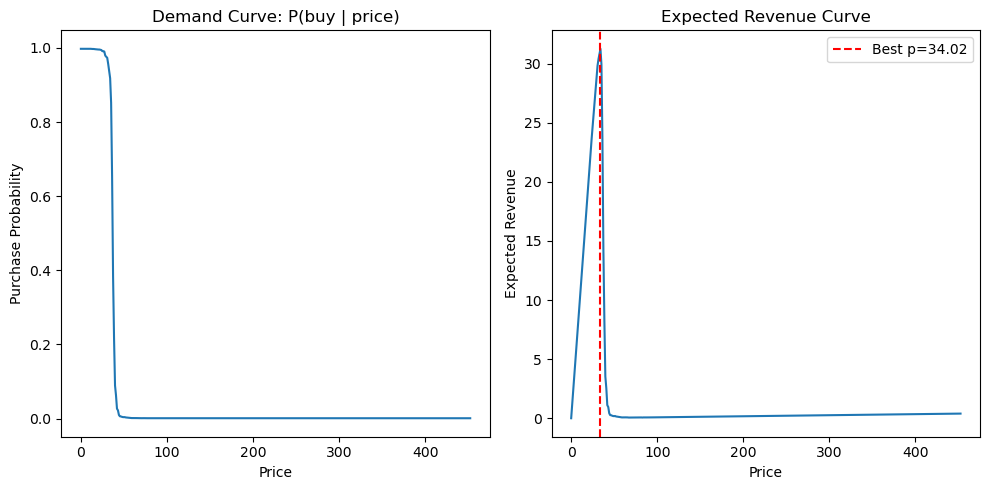

Best price = 34.0197, Expected Revenue = 31.242885


In [44]:
import matplotlib.pyplot as plt

example_covs = test_df.iloc[0][["Covariate1", "Covariate2", "Covariate3"]].values

def predict_prob(covs, price):
    row = pd.DataFrame([{
        "price_item": price,
        "Covariate1": covs[0],
        "Covariate2": covs[1],
        "Covariate3": covs[2],
    }])
    Xs = scaler.transform(row)
    return best_model.predict_proba(Xs)[0, 1]

def expected_revenue(covs, price):
    return price * predict_prob(covs, price)

#evaluate curves on a fine grid
PLOT_GRID = np.linspace(0.01, 452.339, 400)

probs = np.array([predict_prob(example_covs, p) for p in PLOT_GRID])
evs   = np.array([expected_revenue(example_covs, p) for p in PLOT_GRID])

best_idx = evs.argmax()
best_price = PLOT_GRID[best_idx]
best_ev = evs[best_idx]

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(PLOT_GRID, probs)
plt.title("Demand Curve: P(buy | price)")
plt.xlabel("Price")
plt.ylabel("Purchase Probability")

plt.subplot(1,2,2)
plt.plot(PLOT_GRID, evs)
plt.axvline(best_price, color='red', linestyle='--', label=f"Best p={best_price:.2f}")
plt.title("Expected Revenue Curve")
plt.xlabel("Price")
plt.ylabel("Expected Revenue")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Best price = {best_price:.4f}, Expected Revenue = {best_ev:.6f}")

In [45]:
import numpy as np

train_covariate_cols = ["Covariate1", "Covariate2", "Covariate3"]

def best_price_and_expected_rev_for_one_user(covariate_series):
    #matched the logic from our agent file
    x_raw = np.zeros((len(price_grid), 4))
    x_raw[:, 0] = price_grid
    x_raw[:, 1] = covariate_series["Covariate1"]
    x_raw[:, 2] = covariate_series["Covariate2"]
    x_raw[:, 3] = covariate_series["Covariate3"]

    feature_columns = ["price_item", "Covariate1", "Covariate2", "Covariate3"]
    x_raw = pd.DataFrame(x_raw, columns=feature_columns)

    x_scaled = loaded_scaler.transform(x_raw)
    probs = loaded_model.predict_proba(x_scaled)[:, 1]
    evs = price_grid * probs

    idx = int(np.argmax(evs))
    return float(price_grid[idx]), float(evs[idx])

#use the same price_grid as our .py file
price_grid = np.linspace(0.01, 452.339045127419, 100)

evs = []
for _, user in train_df.iterrows():
    covariate_series = user[train_covariate_cols]
    _, ev_star = best_price_and_expected_rev_for_one_user(covariate_series)
    evs.append(ev_star)

evs = np.array(evs)
print("First 10 EV*:", evs[:10])
print("Min EV*:", evs.min())
print("Max EV*:", evs.max())
print("Avg EV*:", evs.mean())

First 10 EV*: [91.85565499 49.78811973 84.678846   57.75890585 48.67210042  9.06432533
 61.24860083 45.38655056 31.66391084 52.99651734]
Min EV*: 0.5846473069350304
Max EV*: 343.28441333659316
Avg EV*: 63.62204669542003


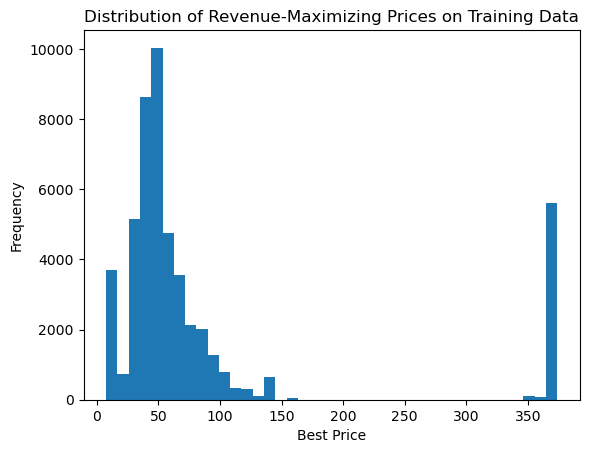

Best Price Distribution Quantiles:
  25th percentile: 37.83
  50th percentile (median): 51.45
  75th percentile: 74.14
  90th percentile: 364.60


In [ ]:
temp_grid = np.linspace(0.01, price_max, 300)

best_prices = []

for x_row in x.values:
    #repeat the row across the grid
    x_grid = np.tile(x_row, (len(temp_grid), 1))
    
    #replace price column with the grid
    x_grid[:, 0] = temp_grid 

    feature_columns = ["price_item", "Covariate1", "Covariate2", "Covariate3"]
    x_raw = pd.DataFrame(x_raw, columns=feature_columns)
    
    x_scaled = loaded_scaler.transform(x_grid)
    probs = loaded_model.predict_proba(x_scaled)[:, 1]

    revenue = probs * temp_grid
    best_prices.append(temp_grid[np.argmax(revenue)])

#convert to array for quantiles
best_prices = np.array(best_prices)

plt.hist(best_prices, bins=40)
plt.title("Distribution of Revenue-Maximizing Prices on Training Data")
plt.xlabel("Best Price")
plt.ylabel("Frequency")
plt.show()

q25, q50, q75, q90 = np.percentile(best_prices, [25, 50, 75, 90])
print("Best Price Distribution Quantiles:")
print(f"  25th percentile: {q25:.2f}")
print(f"  50th percentile (median): {q50:.2f}")
print(f"  75th percentile: {q75:.2f}")
print(f"  90th percentile: {q90:.2f}")